# EDA: feature engineering parameters

Exploration only, nothing here is load-bearing. Goal: pick a rolling window size and Savitzky-Golay filter parameters for `src/features.py` by looking at what actually smooths sensor noise without erasing the real degradation trend, instead of guessing.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from src.load import load_train, SENSOR_COLS

%matplotlib inline

## Which sensor actually shows a degradation trend?

Using FD001 (single condition, no regime confound) so this is about smoothing choice, not regime mixing. Rank sensors by how strongly they correlate with cycle number within a unit, averaged across units.

A sensor's correlation with cycle is undefined for any unit where that sensor happens to be constant for that unit's whole life (zero variance) — not just for sensors that are globally constant. `safe_unit_corr` checks variance per unit before computing, and skips (NaN, excluded from the mean) rather than letting numpy divide by zero.

In [2]:
df = load_train("FD001")


def safe_unit_corr(g, sensor_col):
    if g[sensor_col].std() == 0 or g["cycle"].std() == 0:
        return float("nan")
    return g["cycle"].corr(g[sensor_col])


corrs = {}
for s in SENSOR_COLS:
    per_unit_corr = df.groupby("unit").apply(safe_unit_corr, sensor_col=s, include_groups=False)
    corrs[s] = per_unit_corr.abs().mean()

for s, c in sorted(corrs.items(), key=lambda x: -x[1])[:8]:
    print(f"{s}: avg |corr| with cycle = {c:.3f}")

s11: avg |corr| with cycle = 0.811
s12: avg |corr| with cycle = 0.790
s4: avg |corr| with cycle = 0.782
s7: avg |corr| with cycle = 0.762
s15: avg |corr| with cycle = 0.725
s21: avg |corr| with cycle = 0.717
s20: avg |corr| with cycle = 0.714
s13: avg |corr| with cycle = 0.687


**s11 wins** (avg |corr| ~0.81). Use it to compare smoothing options on a single engine.

Unit 1 is used below with no particular justification — it's just the first unit in the file, picked for convenience. Whether that matters is checked explicitly in the "different lifespans" section further down, rather than assumed.

## Raw vs. rolling mean vs. Savitzky-Golay

Same unit, same sensor, several candidate parameters overlaid.

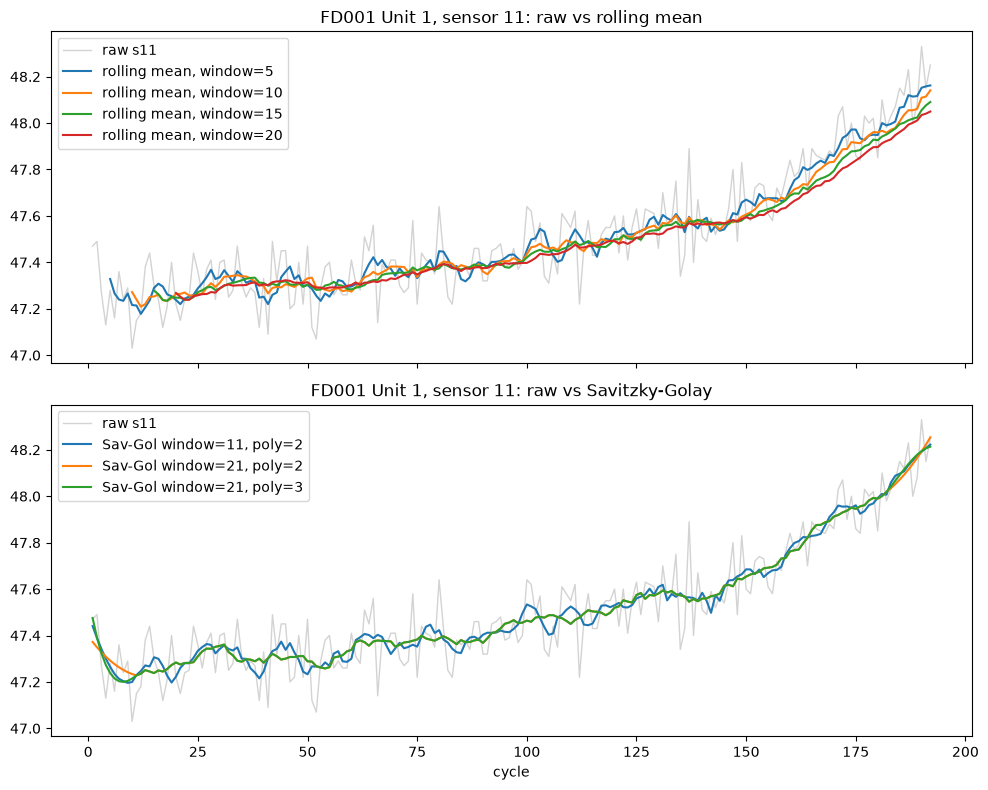

In [3]:
unit = df[df["unit"] == 1].sort_values("cycle")
x = unit["cycle"].values
y = unit["s11"].values

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(x, y, color="lightgray", label="raw s11", linewidth=1)
ax.plot(x, unit["s11"].rolling(5).mean(), label="rolling mean, window=5")
ax.plot(x, unit["s11"].rolling(10).mean(), label="rolling mean, window=10")
ax.plot(x, unit["s11"].rolling(15).mean(), label="rolling mean, window=15")
ax.plot(x, unit["s11"].rolling(20).mean(), label="rolling mean, window=20")
ax.set_title("FD001 Unit 1, sensor 11: raw vs rolling mean")
ax.legend()

ax = axes[1]
ax.plot(x, y, color="lightgray", label="raw s11", linewidth=1)
ax.plot(x, savgol_filter(y, window_length=11, polyorder=2), label="Sav-Gol window=11, poly=2")
ax.plot(x, savgol_filter(y, window_length=21, polyorder=2), label="Sav-Gol window=21, poly=2")
ax.plot(x, savgol_filter(y, window_length=21, polyorder=3), label="Sav-Gol window=21, poly=3")
ax.set_title("FD001 Unit 1, sensor 11: raw vs Savitzky-Golay")
ax.set_xlabel("cycle")
ax.legend()

plt.tight_layout()
plt.show()

## Does window=15 / Sav-Gol=21 hold up across different engine lifespans?

Unit 1 was picked arbitrarily. Checking the shortest, median, and longest FD001 units instead, to see whether the smoothing choice is an artifact of that one arbitrary pick.

shortest: unit 39 (128 cycles)
median:   unit 26 (199 cycles)
longest:  unit 69 (362 cycles)


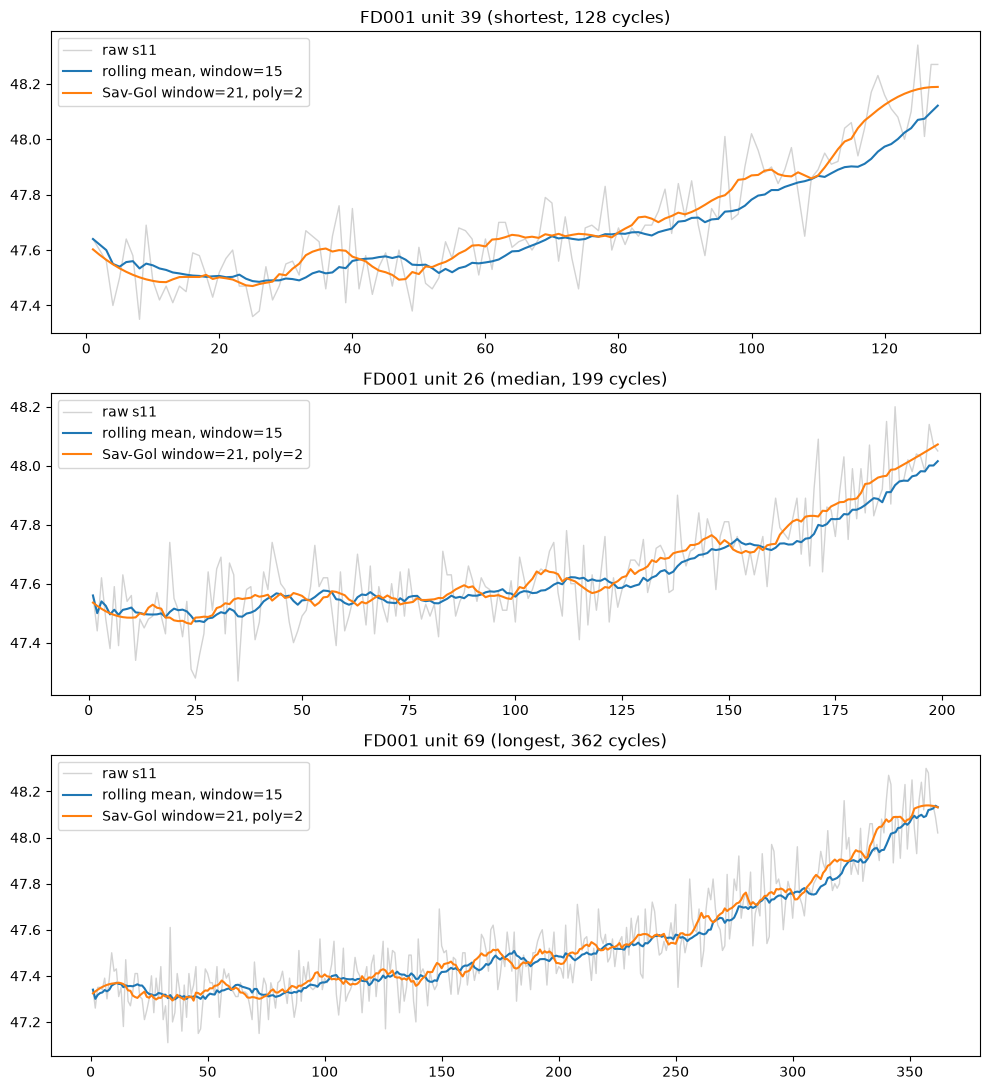

In [4]:
lengths = df.groupby("unit")["cycle"].max()
short_unit = lengths.idxmin()
median_unit = lengths.sub(lengths.median()).abs().idxmin()
long_unit = lengths.idxmax()
print(f"shortest: unit {short_unit} ({lengths[short_unit]} cycles)")
print(f"median:   unit {median_unit} ({lengths[median_unit]} cycles)")
print(f"longest:  unit {long_unit} ({lengths[long_unit]} cycles)")

fig, axes = plt.subplots(3, 1, figsize=(10, 11))

for ax, (uid, label) in zip(axes, [(short_unit, "shortest"), (median_unit, "median"), (long_unit, "longest")]):
    u = df[df["unit"] == uid].sort_values("cycle")
    ux = u["cycle"].values
    uy = u["s11"].values
    ax.plot(ux, uy, color="lightgray", label="raw s11", linewidth=1)
    ax.plot(ux, u["s11"].rolling(15, min_periods=1).mean(), label="rolling mean, window=15")
    ax.plot(ux, savgol_filter(uy, window_length=21, polyorder=2), label="Sav-Gol window=21, poly=2")
    ax.set_title(f"FD001 unit {uid} ({label}, {lengths[uid]} cycles)")
    ax.legend()

plt.tight_layout()
plt.show()

**Finding:** smoothing quality and lag look consistent across the shortest (128 cycles), median (199), and longest (362) engines — no degradation at either extreme. Unit 1's length (192) happened to be close to the median anyway, but this isn't relying on that luck.

## Does the same window size hold up on FD004 (6 regimes, 2 fault modes), the most different dataset?

FD004's raw sensor values are dominated by 6 mixed flight conditions, which swamp any wear trend — correlating a raw sensor with cycle number here would be meaningless until regime normalization (`src/regimes.py`) removes that confound. So this check uses `fit_regimes()` output, matching what `features.py` will actually receive.

In [5]:
from src.regimes import fit_regimes

df4 = load_train("FD004")
df4_norm, _fitted4 = fit_regimes(df4)

corrs4 = {}
for s in SENSOR_COLS:
    per_unit_corr = df4_norm.groupby("unit").apply(safe_unit_corr, sensor_col=s, include_groups=False)
    corrs4[s] = per_unit_corr.abs().mean()

for s, c in sorted(corrs4.items(), key=lambda x: -x[1])[:8]:
    print(f"{s}: avg |corr| with cycle = {c:.3f}")

s11: avg |corr| with cycle = 0.783
s15: avg |corr| with cycle = 0.749
s4: avg |corr| with cycle = 0.727
s14: avg |corr| with cycle = 0.713
s9: avg |corr| with cycle = 0.697
s17: avg |corr| with cycle = 0.648
s3: avg |corr| with cycle = 0.619
s12: avg |corr| with cycle = 0.610


**s11 wins again** (~0.78, close to FD001's 0.81) — the trend structure is comparable once regime-normalized. Plot it the same way as FD001.

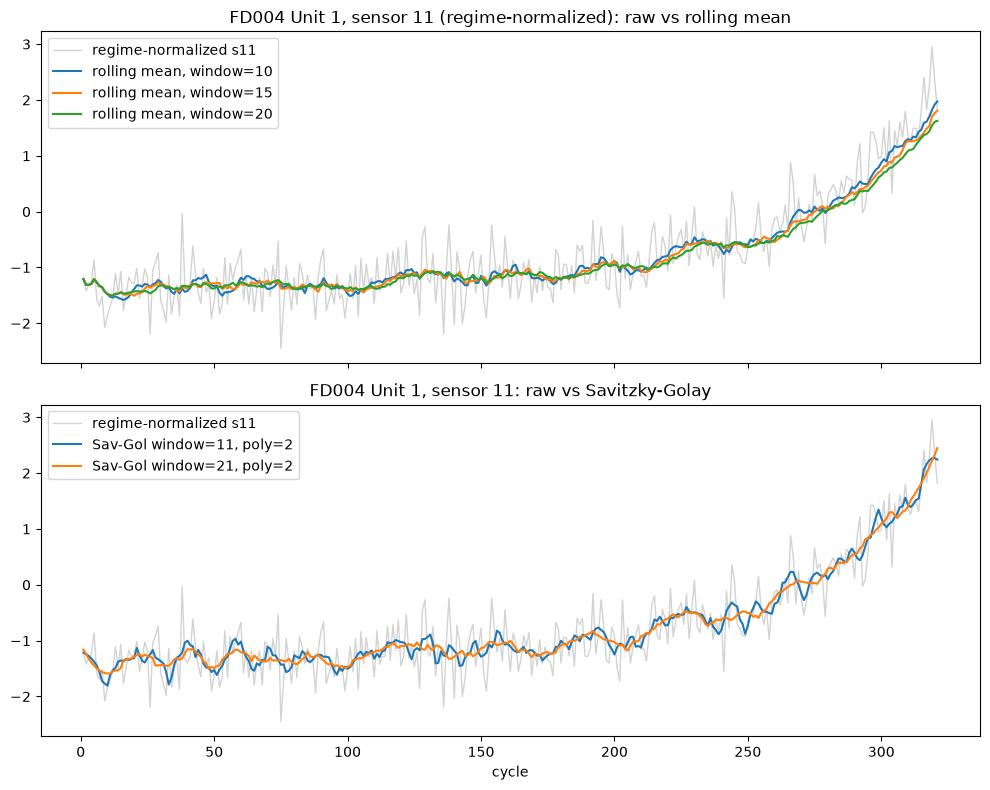

In [6]:
unit4 = df4_norm[df4_norm["unit"] == 1].sort_values("cycle")
x4 = unit4["cycle"].values
y4 = unit4["s11"].values

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(x4, y4, color="lightgray", label="regime-normalized s11", linewidth=1)
ax.plot(x4, unit4["s11"].rolling(10, min_periods=1).mean(), label="rolling mean, window=10")
ax.plot(x4, unit4["s11"].rolling(15, min_periods=1).mean(), label="rolling mean, window=15")
ax.plot(x4, unit4["s11"].rolling(20, min_periods=1).mean(), label="rolling mean, window=20")
ax.set_title("FD004 Unit 1, sensor 11 (regime-normalized): raw vs rolling mean")
ax.legend()

ax = axes[1]
ax.plot(x4, y4, color="lightgray", label="regime-normalized s11", linewidth=1)
ax.plot(x4, savgol_filter(y4, window_length=11, polyorder=2), label="Sav-Gol window=11, poly=2")
ax.plot(x4, savgol_filter(y4, window_length=21, polyorder=2), label="Sav-Gol window=21, poly=2")
ax.set_title("FD004 Unit 1, sensor 11: raw vs Savitzky-Golay")
ax.set_xlabel("cycle")
ax.legend()

plt.tight_layout()
plt.show()

**Finding:** window=15 sits between window=10 and window=20 the same way it did on FD001, and Sav-Gol window=21 tracks the steep late-life rise cleanly without window=11's extra wiggle. FD004 — the most structurally different dataset — behaves the same way at these settings.

## Conclusion

**Rolling window = 15, Savitzky-Golay window = 21, polyorder = 2** — applied uniformly to all four datasets via the same function in `src/features.py`, not tuned per dataset. Confirmed across: the two bookend datasets (FD001, FD004), the shortest/median/longest engine lifespans within FD001, and (via `s11`'s consistently strong correlation) the values feeding into the smoothing step whether raw (FD001/FD003) or regime-normalized (FD002/FD004).